<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

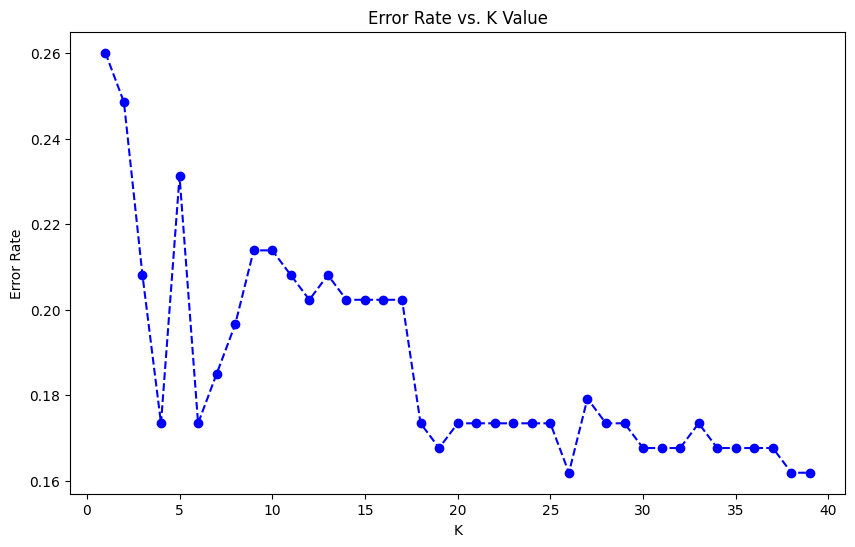

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.70      0.73        76
           1       0.78      0.82      0.80        97

    accuracy                           0.77       173
   macro avg       0.77      0.76      0.76       173
weighted avg       0.77      0.77      0.77       173



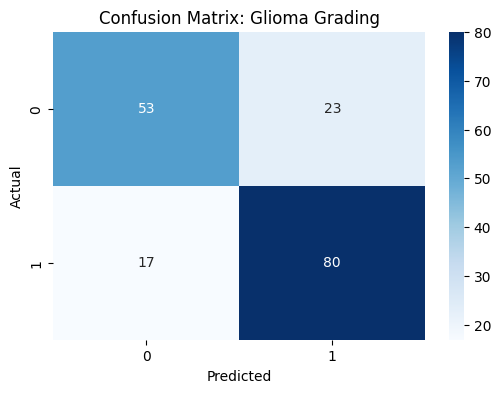

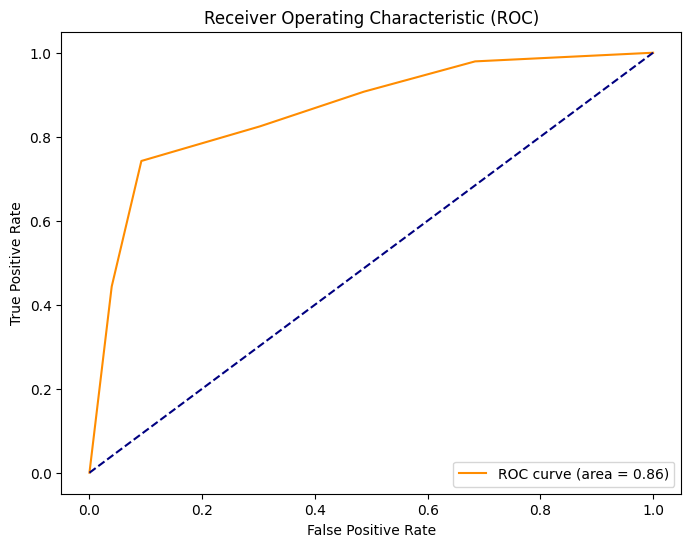

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

# 1. Load Dataset (Assuming file is named 'glioma.csv')
# The dataset contains Grade (Target), Gender, Age_at_diagnosis, Race, and 20 Mutation genes.
df = pd.read_csv('TCGA_GBM_LGG_Mutations_all.csv')

# 2. Data Preprocessing
# Convert Target: LGG -> 0, GBM -> 1
le = LabelEncoder()
df['Grade'] = le.fit_transform(df['Grade'])

# Handling Categorical Clinical Features (Gender & Race)
df['Gender'] = le.fit_transform(df['Gender'])
df['Race'] = le.fit_transform(df['Race'])

# Mutations are usually 'NOT_MUTATED' or 'MUTATED'. Convert to 0 and 1.
mutation_cols = df.columns[4:] # Adjust index based on your CSV structure
for col in mutation_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'MUTATED' else 0)

# 3. Feature Selection & Scaling
X = df.drop(['Grade', 'Case_ID', 'Project'], axis=1, errors='ignore')
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model Training: K-Nearest Neighbors (KNN)
# We use KNN here to show non-linear separation before moving to SVM in Lab 7.
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Plot Elbow Method
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# Selecting optimal K (e.g., k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

# 5. Evaluation Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Glioma Grading')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()